**Initialize**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['time', 'long', 'x', 'y', 'z']
r_hek = pd.read_csv('HEKTOR.aei', sep='\s+', skiprows=4, names=cols)
r_jup = pd.read_csv('JUPITER.aei', sep='\s+', skiprows=4, names=cols)

**ICRF**

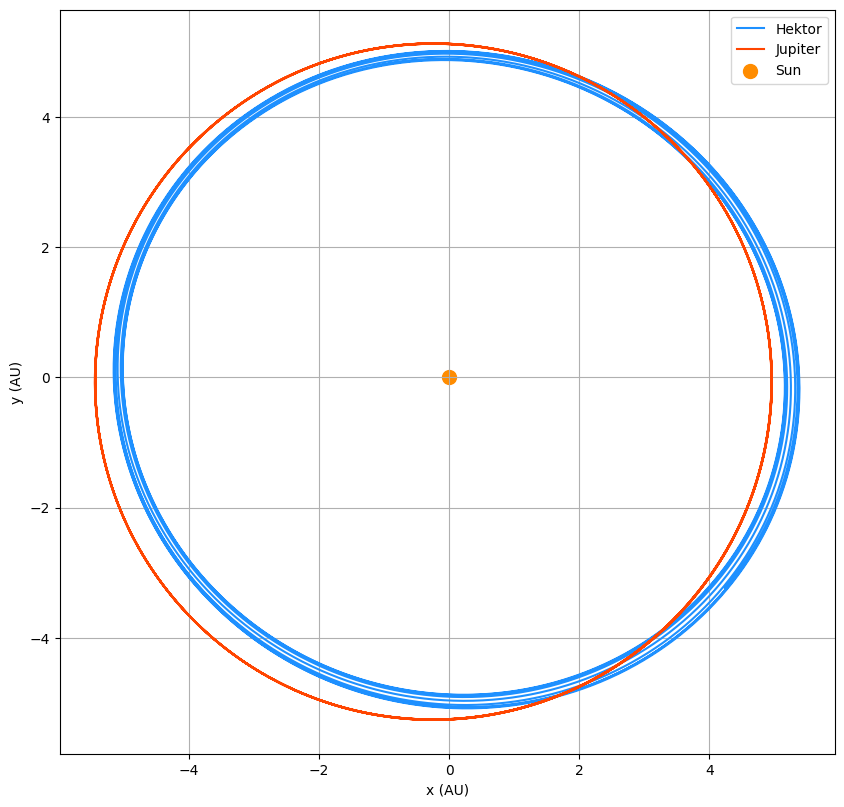

In [42]:
plt.figure(figsize=(10, 10))

plt.plot(r_hek['x'], r_hek['y'], label='Hektor', color='dodgerblue')
plt.plot(r_jup['x'], r_jup['y'], label='Jupiter', color='orangered')
plt.scatter([0], [0], color='darkorange', s=100, label='Sun')

plt.gca().set_aspect('equal')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.legend()
plt.grid(True)
plt.show()

**Jupiter-centric coordinates**

In [ ]:
theta_jup = np.arctan2(r_jup['y'], r_jup['x'])

hek_x_rot = r_hek['x'] * np.cos(theta_jup) + r_hek['y'] * np.sin(theta_jup)
hek_y_rot = -r_hek['x'] * np.sin(theta_jup) + r_hek['y'] * np.cos(theta_jup)

jup_x_rot = r_jup['x'] * np.cos(theta_jup) + r_jup['y'] * np.sin(theta_jup)
jup_y_rot = np.zeros_like(jup_x_rot)

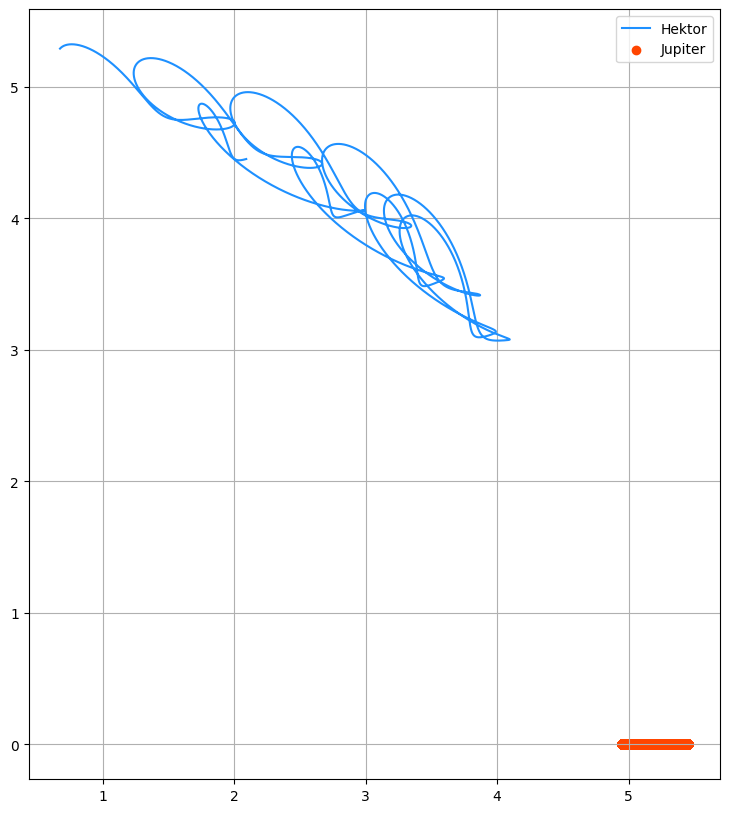

In [43]:
plt.figure(figsize=(10, 10))

plt.plot(hek_x_rot, hek_y_rot, label='Hektor', color='dodgerblue')
plt.scatter(jup_x_rot, jup_y_rot, label='Jupiter', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()

**HORIZONS Data**

In [22]:
from astroquery.jplhorizons import Horizons
import numpy as np

start_jd = 2458400.5
duration_yrs = 100
epochs = start_jd + np.arange(0, duration_yrs * 365.25, 365.25)

obj_h = Horizons(id='Hektor', location='@sun', epochs=epochs)
vec_h = obj_h.vectors()

obj_j = Horizons(id='5', location='@sun', epochs=epochs)
vec_j = obj_j.vectors()

h_real_x, h_real_y = np.array(vec_h['x']), np.array(vec_h['y'])
j_real_x, j_real_y = np.array(vec_j['x']), np.array(vec_j['y'])

theta_real = np.arctan2(j_real_y, j_real_x)

h_real_x_rot = h_real_x * np.cos(theta_real) + h_real_y * np.sin(theta_real)
h_real_y_rot = -h_real_x * np.sin(theta_real) + h_real_y * np.cos(theta_real)

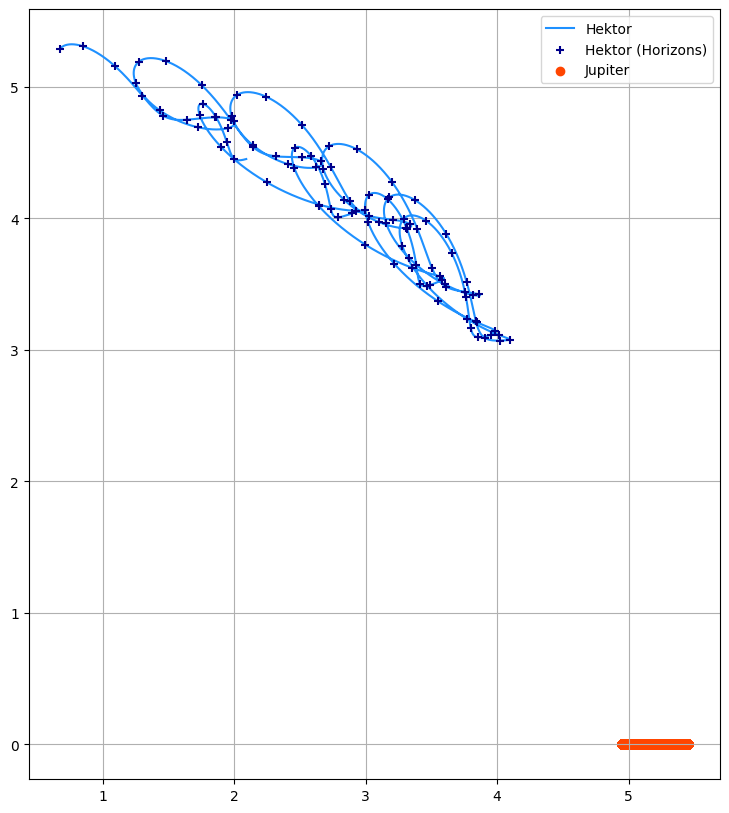

In [46]:
plt.figure(figsize=(10, 10))

plt.plot(hek_x_rot, hek_y_rot, label='Hektor', color='dodgerblue')
plt.scatter(h_real_x_rot, h_real_y_rot, label='Hektor (Horizons)', color='darkblue', marker='+', s=30, zorder=5)
plt.scatter(jup_x_rot, jup_y_rot, label='Jupiter', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()